In [1]:
import sys
import platform

print("Python version:", sys.version)
print("Implementation:", platform.python_implementation())


Python version: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
Implementation: CPython


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\utente\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Found 19 subfolders.

Loaded 19 subfolders with results.
Saved SVG → kruskal_grid_plot.svg


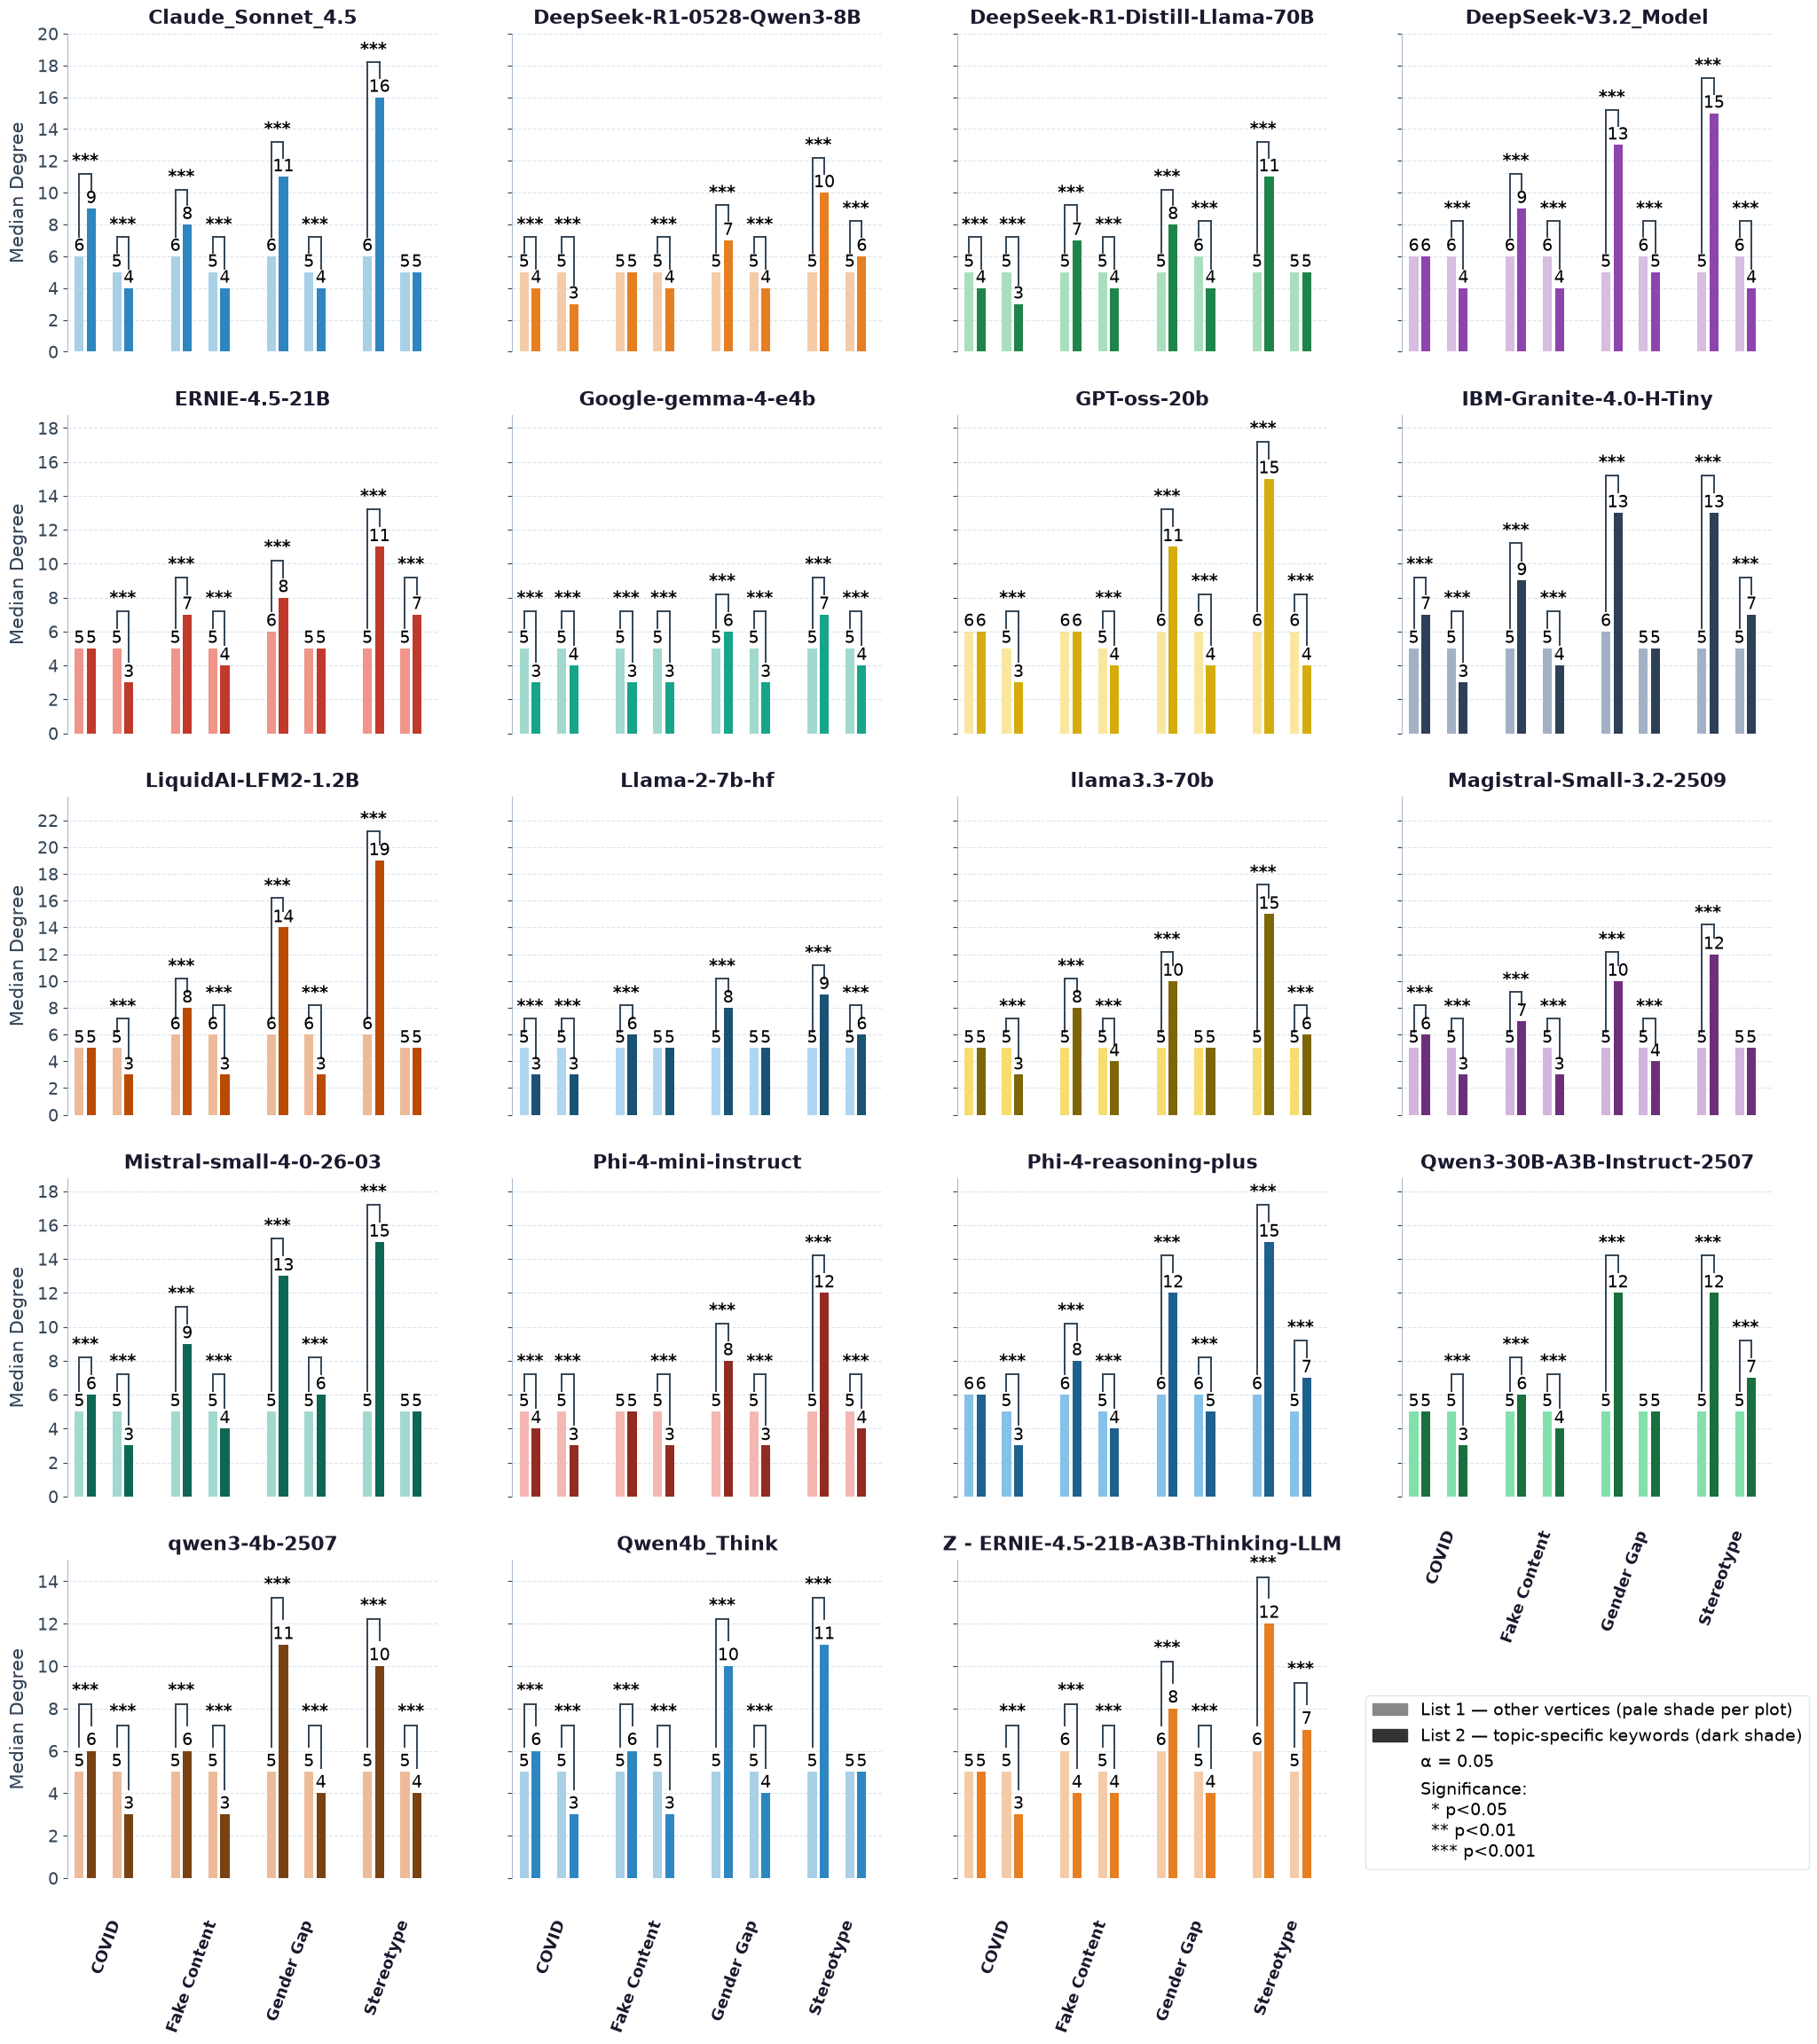

Saved PDF → kruskal_grid_plot.pdf

Saved → kruskal_grid_plot.png


<Figure size 640x480 with 0 Axes>

In [2]:

# Main code used in article



import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
from pathlib import Path
from scipy.stats import kruskal
import nltk
from nltk.corpus import stopwords

# =========================
# READABILITY FIXES ONLY
# =========================
mpl.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
    "font.family": "DejaVu Sans",
})

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# =========================
# CONFIG
# =========================
root_folder = r"C:\Users\utente\Documents\UniTrento\PENSO\ConvinceMe\Repo\ConvinceMe\ProcessedData_ConstraintsFixes\Hypothesis_Testing"  # folder containing the 19 subfolders
output_file = "kruskal_grid_plot.png"

COLS_PER_ROW = 4
ALPHA = 0.05
NORMALIZE_TOKENS = True

LAYER_COLUMNS = {
    "opinion": "opinion_Edge",
    "reasoning_summary": "reasoning_summary_Edge",
}

topic_keywords = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.": ['vaccine', 'health', 'covid', 'healthcare'],
    "How to manage and dealing with fake content on social media.": ['fake', 'social', 'media', 'content'],
    "What is the gender gap in science? Should we address it? And how?": ['gender', 'gap', 'science'],
    "What is stereotype threat in STEM? Should we address it? And how?": ['stereotype', 'STEM', 'threat'],
}

short_labels = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion": "Vaccine\nOpinion",
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary": "Vaccine\nReasoning",
    "How to manage and dealing with fake content on social media.|||opinion": "FakeNews\nOpinion",
    "How to manage and dealing with fake content on social media.|||reasoning_summary": "FakeNews\nReasoning",
    "What is the gender gap in science? Should we address it? And how?|||opinion": "GenderGap\nOpinion",
    "What is the gender gap in science? Should we address it? And how?|||reasoning_summary": "GenderGap\nReasoning",
    "What is stereotype threat in STEM? Should we address it? And how?|||opinion": "Stereotype\nOpinion",
    "What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary": "Stereotype\nReasoning",
}

topic_groups = {
    "COVID Vaccines & Healthcare": [
        "How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion",
        "How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary",
    ],
    "Fake Content on Social Media": [
        "How to manage and dealing with fake content on social media.|||opinion",
        "How to manage and dealing with fake content on social media.|||reasoning_summary",
    ],
    "Gender Gap in Science": [
        "What is the gender gap in science? Should we address it? And how?|||opinion",
        "What is the gender gap in science? Should we address it? And how?|||reasoning_summary",
    ],
    "Stereotype Threat in STEM": [
        "What is stereotype threat in STEM? Should we address it? And how?|||opinion",
        "What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary",
    ],
}

KEY_FILE_MAP = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion": "Vaccine_Op",
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary": "Vaccine_RS",
    "How to manage and dealing with fake content on social media.|||opinion": "fakeNews_Op",
    "How to manage and dealing with fake content on social media.|||reasoning_summary": "fakeNews_RS",
    "What is the gender gap in science? Should we address it? And how?|||opinion": "genderGap_Op",
    "What is the gender gap in science? Should we address it? And how?|||reasoning_summary": "genderGap_RS",
    "What is stereotype threat in STEM? Should we address it? And how?|||opinion": "stereotypeThreat_Op",
    "What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary": "stereotypeThreat_RS",
}

# (dark — list2 topic keywords, pale — list1 other vertices)
SUBPLOT_COLORS = [
    ("#2E86C1", "#A8D0E6"),  # blue / pale blue
    ("#E67E22", "#F5CBA7"),  # orange / pale orange
    ("#1E8449", "#A9DFBF"),  # green / pale green
    ("#8E44AD", "#D7BDE2"),  # purple / pale purple
    ("#C0392B", "#F1948A"),  # red / pale red
    ("#17A589", "#A2D9CE"),  # teal / pale teal
    ("#D4AC0D", "#F9E79F"),  # yellow / pale yellow
    ("#2E4057", "#A3B1C6"),  # navy / pale navy
    ("#BA4A00", "#EDBB99"),  # brown / pale brown
    ("#1A5276", "#AED6F1"),  # dark blue / pale blue
    ("#7D6608", "#F7DC6F"),  # olive / pale olive
    ("#6E2F7A", "#D2B4DE"),  # dark purple / pale purple
    ("#0E6655", "#A2D9CE"),  # dark teal / pale teal
    ("#922B21", "#F5B7B1"),  # dark red / pale red
    ("#1F618D", "#85C1E9"),  # steel blue / pale steel blue
    ("#196F3D", "#82E0AA"),  # forest green/ pale green
    ("#784212", "#EDBB99"),  # dark brown / pale brown
]

C_SIG = "#C0392B"

# =========================
# HELPERS
# =========================
def normalize_token(t: str) -> str:
    return t.strip().lower() if NORMALIZE_TOKENS else t.strip()

def sig_label(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def load_subfolder(subfolder: Path) -> dict:
    tlv = {}
    for key, filename in KEY_FILE_MAP.items():
        pkl_file = subfolder / f"{filename}.pkl"
        if not pkl_file.exists():
            print(f" WARNING: {pkl_file.name} not found in {subfolder.name}")
            continue
        tlv[key] = pd.read_pickle(pkl_file)
    return tlv

def compute_kw_results(topic_layer_vertices: dict) -> dict:
    kw_results = {}
    for topic, keywords in topic_keywords.items():
        topic_words = set(normalize_token(w) for w in topic.replace("?", "").replace(".", "").split())
        exclude = stop_words | topic_words | set(k.lower() for k in keywords)

        for layer in LAYER_COLUMNS.keys():
            key = f"{topic}|||{layer}"
            if key not in topic_layer_vertices:
                continue

            df = topic_layer_vertices[key]
            mask_kw = df["vertex"].isin([k.lower() for k in keywords])
            list2 = [d for dl in df[mask_kw]["degree_list"] for d in dl]

            mask_other = ~df["vertex"].isin(exclude)
            list1 = [d for dl in df[mask_other]["degree_list"] for d in dl]

            if len(list1) < 2 or len(list2) < 2:
                continue

            stat, p = kruskal(list1, list2)

            kw_results[key] = {
                "median_list1": np.median(list1),
                "median_list2": np.median(list2),
                "H": stat,
                "p": p,
                "reject": p < ALPHA,
            }
    return kw_results

def draw_subplot(ax, kw_results, title, show_ylabel, y_max, colors, idx, n_rows, n_cols, n):
    c_dark, c_pale = colors
    bar_w = 0.30
    pair_gap = 0.10
    group_gap = 0.70

    x_centers = []
    x = 0.0
    group_boundaries = []

    for t_label, group_keys in topic_groups.items():
        g_start = x
        for key in group_keys:
            if key not in kw_results:
                continue
            x_centers.append((key, x))
            x += bar_w * 2 + pair_gap + 0.55
        g_end = x - 0.55
        group_boundaries.append((g_start, g_end, t_label))
        x += group_gap

    if not x_centers:
        ax.set_visible(False)
        return

    last_row_start = (n_rows - 1) * n_cols
    n_last_row = n % n_cols if n % n_cols != 0 else n_cols
    orphan_start = last_row_start - n_cols + n_last_row
    is_last_row = (idx >= last_row_start) or (idx >= orphan_start and idx < last_row_start)

    ax.set_facecolor("white")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, color="#dde4ec", zorder=0)
    ax.set_axisbelow(True)

    for key, xc in x_centers:
        r = kw_results[key]
        m1 = r["median_list1"]
        m2 = r["median_list2"]

        x1 = xc
        x2 = xc + bar_w + pair_gap

        ax.bar(x1, m1, width=bar_w, color=c_pale, zorder=3, linewidth=0)
        ax.bar(x2, m2, width=bar_w, color=c_dark, zorder=3, linewidth=0)

        # value labels on top of bars (READABLE NOW)
        ax.text(x1, m1 + 0.08, f"{m1:.0f}", ha="center", va="bottom", fontsize=14, color="#000000")
        ax.text(x2, m2 + 0.08, f"{m2:.0f}", ha="center", va="bottom", fontsize=14, color="#000000")

        # significance bracket — skip if medians are equal
        if m1 != m2:
            base_offset = 1.2        # was 0.5 → now higher above bars
            bracket_height = 1.0     # vertical bracket height
            star_offset = 0.25       # star above horizontal line

            y_left = m1 + base_offset
            y_right = m2 + base_offset
            y_top = max(y_left, y_right) + bracket_height

            ax.plot([x1, x1], [y_left, y_top], color="#334455", lw=1.4)
            ax.plot([x2, x2], [y_right, y_top], color="#334455", lw=1.4)
            ax.plot([x1, x2], [y_top, y_top], color="#334455", lw=1.4)

            ax.text((x1 + x2) / 2,
                    y_top + star_offset,
                    sig_label(r["p"]),
                    ha="center",
                    va="bottom",
                    fontsize=14,
                    color="#000000",
                    fontweight="bold")
    
        # sub-label (Opinion / Reasoning) — last row only (READABLE)
        # sub-label (Opinion / Reasoning) — last row only
        # if is_last_row:
        #     sub = short_labels.get(key, key).split("\n")[1]

        #     y_sub = -0.55
        #     if "reasoning_summary" in key:
        #         y_sub = -1   # move reasoning slightly down

        #     ax.text(xc + bar_w + pair_gap / 2, y_sub, sub,
        #             ha="center", va="top",
        #             fontsize=8,  # make sure this is readable
        #             color="#556677")

        # # H value — always shown (READABLE)
        # ax.text(xc + bar_w + pair_gap / 2, -0.95, f"H={r['H']:.1f}",
        #         ha="center", va="top", fontsize=12, color="#000000")

    # topic header labels — last row only, rotated 60° (READABLE)
    if is_last_row:
        header_y = -1.9
        for g_start, g_end, label in group_boundaries:
            short_topic = {
                "COVID Vaccines & Healthcare": "COVID",
                "Fake Content on Social Media": "Fake Content",
                "Gender Gap in Science": "Gender Gap",
                "Stereotype Threat in STEM": "Stereotype",
            }
            ax.text((g_start + g_end) / 2, header_y, short_topic.get(label, label),
                    ha="right", va="top", fontsize=13, fontweight="bold",
                    color="#1a1a2e", rotation=70, rotation_mode="anchor")

    # axes formatting
    ax.set_xlim(-0.4, max(xc for _, xc in x_centers) + bar_w * 2 + 0.5)

    # give extra bottom space only for last row (for rotated labels)
    ax.set_ylim(0, y_max)

    ax.set_xticks([])
    y_ticks = np.arange(0, int(y_max) + 1, 2)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis="y", labelsize=14, colors="#334455")

    if show_ylabel:
        ax.set_ylabel("Median Degree", fontsize=15, color="#334455", labelpad=8)
    else:
        ax.set_yticklabels([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color("#aabbcc")

    ax.set_title(title, fontsize=16, fontweight="bold", color="#1a1a2e", pad=8)

# =========================
# LOAD + COMPUTE all subfolders
# =========================
root = Path(root_folder)
subfolders = sorted([f for f in root.iterdir() if f.is_dir()])
print(f"Found {len(subfolders)} subfolders.")

all_kw = []  # list of (subfolder_name, kw_results, color_pair)
for idx, sf in enumerate(subfolders):
    tlv = load_subfolder(sf)
    if not tlv:
        print(f" Skipping {sf.name} — no PKL files loaded.")
        continue
    kw = compute_kw_results(tlv)
    if kw:
        colors = SUBPLOT_COLORS[idx % len(SUBPLOT_COLORS)]
        all_kw.append((sf.name, kw, colors))

print(f"\nLoaded {len(all_kw)} subfolders with results.")

# =========================
# COMPUTE shared y_max per row
# =========================
n = len(all_kw)
n_cols = COLS_PER_ROW
n_rows = (n + n_cols - 1) // n_cols

row_ymaxes = []
for row_i in range(n_rows):
    row_items = all_kw[row_i * n_cols: (row_i + 1) * n_cols]
    row_max = 0
    for _, kw, _ in row_items:
        for r in kw.values():
            row_max = max(row_max, r["median_list1"], r["median_list2"])
    row_ymaxes.append(row_max * 1.25)

# =========================
# DRAW GRID (ONLY BIGGER CANVAS)
# =========================
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 6.2, n_rows * 5.4),   # was (n_cols*5.5, n_rows*5)
    facecolor="white"
)

# ensure axes is always 2D
if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for idx, (sf_name, kw, colors) in enumerate(all_kw):
    row_i = idx // n_cols
    col_i = idx % n_cols
    ax = axes[row_i][col_i]
    draw_subplot(
        ax, kw,
        title=sf_name,
        show_ylabel=(col_i == 0),
        y_max=row_ymaxes[row_i],
        colors=colors,
        idx=idx,
        n_rows=n_rows,
        n_cols=n_cols,
        n=len(all_kw)
    )

# hide unused axes
for idx in range(len(all_kw), n_rows * n_cols):
    row_i = idx // n_cols
    col_i = idx % n_cols
    axes[row_i][col_i].set_visible(False)

# =========================
# SHARED LEGEND (bottom of figure) — readable
# =========================
p1 = mpatches.Patch(color="#888888", label="List 1 — other vertices (pale shade per plot)")
p2 = mpatches.Patch(color="#333333", label="List 2 — topic-specific keywords (dark shade)")
p3 = mpatches.Patch(color="none", label=f"α = {ALPHA}")
p4 = mpatches.Patch(color="none", label="Significance:\n  * p<0.05\n  ** p<0.01\n  *** p<0.001")

# NEW
row_i = (n_rows - 1)
col_i = n_cols - 1
ax_legend = axes[row_i][col_i]
ax_legend.set_visible(True)
ax_legend.axis("off")
ax_legend.legend(
    handles=[p1, p2, p3, p4],
    loc="lower center",
    # bbox_to_anchor=(0.5, -0.1),
    ncol=1,
    fontsize=14,
    frameon=True,
    framealpha=0.9,
    edgecolor="#dde4ec",
)

plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")  # dpi was 180

svg_file = "kruskal_grid_plot.svg"
pdf_file = "kruskal_grid_plot.pdf"
plt.savefig(svg_file, format="svg", bbox_inches="tight", facecolor="white")
print(f"Saved SVG → {svg_file}")
plt.show()


plt.savefig(pdf_file, format="pdf", bbox_inches="tight", facecolor="white")
print(f"Saved PDF → {pdf_file}")

print(f"\nSaved → {output_file}")

**Size Effect**

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# =========================
# CONFIG — set this to your actual path
# =========================
root_folder = r"C:\Users\utente\Documents\UniTrento\PENSO\ConvinceMe\Repo\ConvinceMe\ProcessedData_ConstraintsFixes\Hypothesis_Testing"  # folder containing the 19 subfolders

ALPHA = 0.05
NORMALIZE_TOKENS = True

LAYER_COLUMNS = {
    "opinion": "opinion_Edge",
    "reasoning_summary": "reasoning_summary_Edge",
}

topic_keywords = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.":
        ['vaccine', 'health', 'covid', 'healthcare'],
    "How to manage and dealing with fake content on social media.":
        ['fake', 'social', 'media', 'content'],
    "What is the gender gap in science? Should we address it? And how?":
        ['gender', 'gap', 'science'],
    "What is stereotype threat in STEM? Should we address it? And how?":
        ['stereotype', 'STEM', 'threat'],
}

KEY_FILE_MAP = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion": "Vaccine_Op",
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary": "Vaccine_RS",
    "How to manage and dealing with fake content on social media.|||opinion": "fakeNews_Op",
    "How to manage and dealing with fake content on social media.|||reasoning_summary": "fakeNews_RS",
    "What is the gender gap in science? Should we address it? And how?|||opinion": "genderGap_Op",
    "What is the gender gap in science? Should we address it? And how?|||reasoning_summary": "genderGap_RS",
    "What is stereotype threat in STEM? Should we address it? And how?|||opinion": "stereotypeThreat_Op",
    "What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary": "stereotypeThreat_RS",
}

# =========================
# HELPERS
# =========================
def normalize_token(t: str) -> str:
    return t.strip().lower() if NORMALIZE_TOKENS else t.strip()

def load_subfolder(subfolder: Path) -> dict:
    tlv = {}
    for key, filename in KEY_FILE_MAP.items():
        pkl_file = subfolder / f"{filename}.pkl"
        if not pkl_file.exists():
            print(f" WARNING: {pkl_file.name} not found in {subfolder.name}")
            continue
        tlv[key] = pd.read_pickle(pkl_file)
    return tlv

def compute_kw_results(topic_layer_vertices: dict) -> dict:
    kw_results = {}
    for topic, keywords in topic_keywords.items():
        topic_words = set(normalize_token(w) for w in topic.replace("?", "").replace(".", "").split())
        exclude = stop_words | topic_words | set(k.lower() for k in keywords)

        for layer in LAYER_COLUMNS.keys():
            key = f"{topic}|||{layer}"
            if key not in topic_layer_vertices:
                continue

            df = topic_layer_vertices[key]
            mask_kw = df["vertex"].isin([k.lower() for k in keywords])
            list2 = [d for dl in df[mask_kw]["degree_list"] for d in dl]

            mask_other = ~df["vertex"].isin(exclude)
            list1 = [d for dl in df[mask_other]["degree_list"] for d in dl]

            if len(list1) < 2 or len(list2) < 2:
                continue

            stat, p = kruskal(list1, list2)

            # --- effect sizes ---
            u_stat, _ = mannwhitneyu(list1, list2, alternative="two-sided")
            n1, n2 = len(list1), len(list2)
            rank_biserial = 1 - (2 * u_stat) / (n1 * n2)   # -1 to 1
            epsilon_sq = stat / (n1 + n2 - 1)               # 0 to 1
            cles = u_stat / (n1 * n2)                        # 0 to 1

            kw_results[key] = {
                "median_list1": np.median(list1),
                "median_list2": np.median(list2),
                "H": stat,
                "p": p,
                "reject": p < ALPHA,
                "rank_biserial": rank_biserial,
                "epsilon_sq": epsilon_sq,
                "cles": cles,
                "n1": n1,
                "n2": n2,
            }
    return kw_results

# =========================
# LOAD + COMPUTE all subfolders
# =========================
root = Path(root_folder)
subfolders = sorted([f for f in root.iterdir() if f.is_dir()])
print(f"Found {len(subfolders)} subfolders.")

all_kw = []
for sf in subfolders:
    tlv = load_subfolder(sf)
    if not tlv:
        print(f" Skipping {sf.name} — no PKL files loaded.")
        continue
    kw = compute_kw_results(tlv)
    if kw:
        all_kw.append((sf.name, kw))

print(f"\nLoaded {len(all_kw)} subfolders with results.")

# =========================
# BUILD FULL RESULTS TABLE
# =========================
rows = []
for sf_name, kw in all_kw:
    for key, r in kw.items():
        topic, layer = key.split("|||")
        rows.append({
            "model": sf_name,
            "topic": topic,
            "layer": layer,
            "H": r["H"],
            "p": r["p"],
            "significant": r["reject"],
            "rank_biserial": r["rank_biserial"],
            "epsilon_sq": r["epsilon_sq"],
            "cles": r["cles"],
            "median_other": r["median_list1"],
            "median_keywords": r["median_list2"],
            "n1": r["n1"],
            "n2": r["n2"],
        })

results_df = pd.DataFrame(rows)
results_df.to_csv("kruskal_wallis_effect_sizes.csv", index=False)
print(f"\nSaved {len(results_df)} rows → kruskal_wallis_effect_sizes.csv")

# =========================
# SUMMARY
# =========================
print("\n--- Summary across all tests ---")
print(f"Total tests: {len(results_df)}")
print(f"Significant (p<{ALPHA}): {results_df['significant'].sum()} / {len(results_df)}")
print(f"\nRank-biserial correlation: min={results_df['rank_biserial'].min():.3f}, "
      f"max={results_df['rank_biserial'].max():.3f}, median={results_df['rank_biserial'].median():.3f}")
print(f"Epsilon-squared: min={results_df['epsilon_sq'].min():.3f}, "
      f"max={results_df['epsilon_sq'].max():.3f}, median={results_df['epsilon_sq'].median():.3f}")

print("\n--- By layer ---")
print(results_df.groupby("layer")[["rank_biserial", "epsilon_sq"]].median())

print("\n--- By topic ---")
print(results_df.groupby("topic")[["rank_biserial", "epsilon_sq"]].median())

results_df.head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\utente\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Found 19 subfolders.

Loaded 19 subfolders with results.

Saved 152 rows → kruskal_wallis_effect_sizes.csv

--- Summary across all tests ---
Total tests: 152
Significant (p<0.05): 149 / 152

Rank-biserial correlation: min=-0.563, max=0.854, median=0.009
Epsilon-squared: min=0.000, max=0.063, median=0.010

--- By layer ---
                   rank_biserial  epsilon_sq
layer                                       
opinion                 0.346987    0.012422
reasoning_summary      -0.260507    0.009524

--- By topic ---
                                                    rank_biserial  epsilon_sq
topic                                                                        
How to manage and dealing with discussions abou...      -0.340427    0.010001
How to manage and dealing with fake content on ...      -0.118685    0.006435
What is stereotype threat in STEM? Should we ad...       0.334170    0.022649
What is the gender gap in science? Should we ad...       0.108173    0.011293


,model,topic,layer,H,p,significant,rank_biserial,epsilon_sq,cles,median_other,median_keywords,n1,n2
0,Claude_Sonnet_4.5,How to manage and dealing with discussions abo...,opinion,1725.672911,0.000000e+00,True,0.253967,0.004727,0.373016,6.0,9.0,356035,9064
1,Claude_Sonnet_4.5,How to manage and dealing with discussions abo...,reasoning_summary,1925.884796,0.000000e+00,True,-0.398361,0.012178,0.699180,5.0,4.0,154046,4098
2,Claude_Sonnet_4.5,How to manage and dealing with fake content on...,opinion,1565.853811,0.000000e+00,True,0.255619,0.004040,0.372191,6.0,8.0,379502,8078
3,Claude_Sonnet_4.5,How to manage and dealing with fake content on...,reasoning_summary,867.562428,1.105358e-190,True,-0.264389,0.005777,0.632194,5.0,4.0,145978,4194
4,Claude_Sonnet_4.5,What is the gender gap in science? Should we a...,opinion,6747.493928,0.000000e+00,True,0.554162,0.016770,0.222919,6.0,11.0,394955,7390
5,Claude_Sonnet_4.5,What is the gender gap in science? Should we a...,reasoning_summary,950.988232,8.089586e-209,True,-0.256625,0.006362,0.628313,5.0,4.0,144588,4901
6,Claude_Sonnet_4.5,What is stereotype threat in STEM? Should we a...,opinion,11000.379301,0.000000e+00,True,0.712888,0.027864,0.143556,6.0,16.0,387516,7274
7,Claude_Sonnet_4.5,What is stereotype threat in STEM? Should we a...,reasoning_summary,137.720475,8.389216e-32,True,-0.100433,0.000914,0.550216,5.0,5.0,145997,4629
8,DeepSeek-R1-0528-Qwen3-8B,How to manage and dealing with discussions abo...,opinion,202.450674,6.096154e-46,True,-0.084957,0.000648,0.542478,5.0,4.0,302728,9519
9,DeepSeek-R1-0528-Qwen3-8B,How to manage and dealing with discussions abo...,reasoning_summary,1480.549120,0.000000e+00,True,-0.319088,0.009508,0.659544,5.0,3.0,150798,4924


In [13]:
import os
print(os.getcwd())
print([f for f in os.listdir() if 'nltk' in f.lower()])

c:\Users\utente\Documents\UniTrento\PENSO\ConvinceMe\Repo\ConvinceMe\Code\DataArticle_backup_code
[]


In [14]:
# if above code is empty 

!pip uninstall nltk -y
!pip install nltk

Found existing installation: nltk 3.10.3
Uninstalling nltk-3.10.3:
  Successfully uninstalled nltk-3.10.3
  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Final Figure**

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\utente\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Found 19 subfolders.

Loaded 19 subfolders with results.
Saved SVG → kruskal_grid_plot.svg


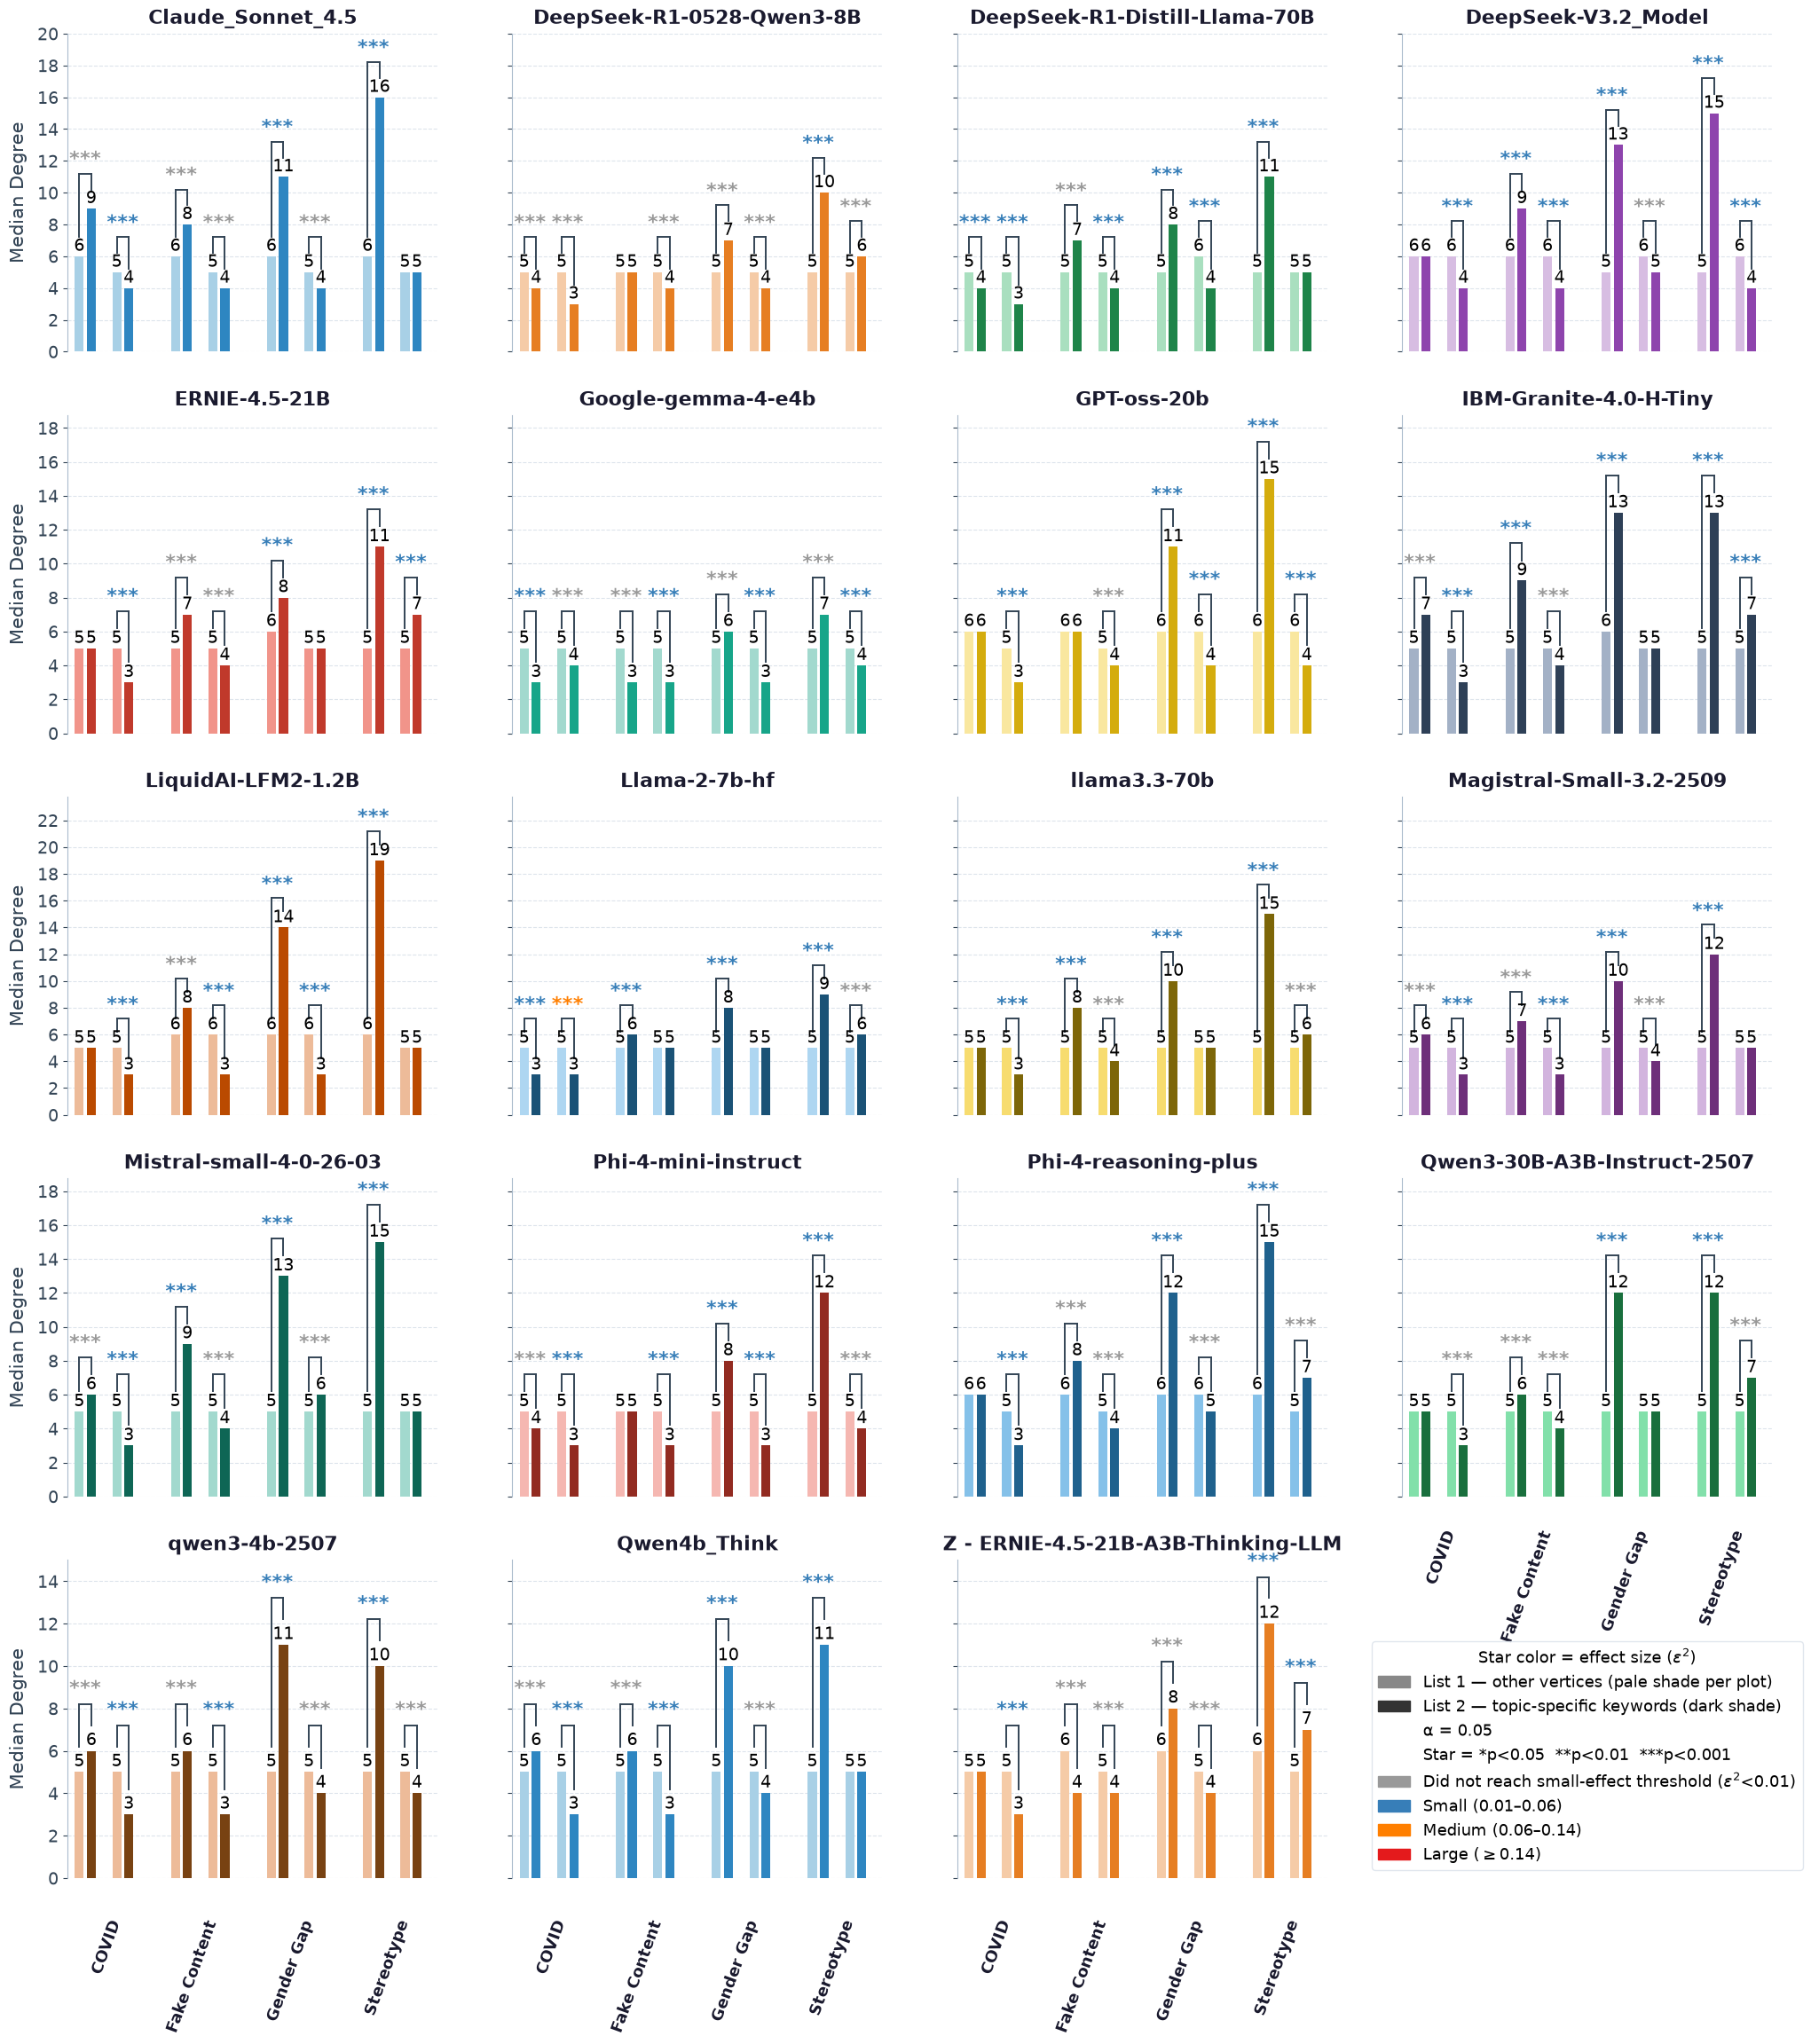

<Figure size 640x480 with 0 Axes>


Saved → kruskal_grid_plot_effectsize.png


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
from pathlib import Path
from scipy.stats import kruskal
import nltk
from nltk.corpus import stopwords

mpl.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
    "font.family": "DejaVu Sans",
})

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# =========================
# CONFIG
# =========================
root_folder = r"C:\Users\utente\Documents\UniTrento\PENSO\ConvinceMe\Repo\ConvinceMe\ProcessedData_ConstraintsFixes\Hypothesis_Testing"
output_file = "kruskal_grid_plot_effectsize.png"

COLS_PER_ROW = 4
ALPHA = 0.05
NORMALIZE_TOKENS = True

# Epsilon-squared thresholds (Cohen, 1988 convention, extended to rank-based effect sizes)
EFFECT_THRESHOLDS = {
    "small":  (0.01, 0.06),
    "medium": (0.06, 0.14),
    "large":  (0.14, 1.01),
}

EFFECT_COLORS = {
    "small":            "#377EB8",  # blue
    "medium":           "#FF7F00",  # orange
    "large":            "#E41A1C",  # red
    "below_threshold":  "#999999",  # gray, for epsilon_sq < 0.01
}

LAYER_COLUMNS = {
    "opinion": "opinion_Edge",
    "reasoning_summary": "reasoning_summary_Edge",
}

topic_keywords = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.":
        ['vaccine', 'health', 'covid', 'healthcare'],
    "How to manage and dealing with fake content on social media.":
        ['fake', 'social', 'media', 'content'],
    "What is the gender gap in science? Should we address it? And how?":
        ['gender', 'gap', 'science'],
    "What is stereotype threat in STEM? Should we address it? And how?":
        ['stereotype', 'STEM', 'threat'],
}

topic_groups = {
    "COVID Vaccines & Healthcare": [
        "How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion",
        "How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary",
    ],
    "Fake Content on Social Media": [
        "How to manage and dealing with fake content on social media.|||opinion",
        "How to manage and dealing with fake content on social media.|||reasoning_summary",
    ],
    "Gender Gap in Science": [
        "What is the gender gap in science? Should we address it? And how?|||opinion",
        "What is the gender gap in science? Should we address it? And how?|||reasoning_summary",
    ],
    "Stereotype Threat in STEM": [
        "What is stereotype threat in STEM? Should we address it? And how?|||opinion",
        "What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary",
    ],
}

KEY_FILE_MAP = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||opinion": "Vaccine_Op",
    "How to manage and dealing with discussions about healthcare and COVID vaccines.|||reasoning_summary": "Vaccine_RS",
    "How to manage and dealing with fake content on social media.|||opinion": "fakeNews_Op",
    "How to manage and dealing with fake content on social media.|||reasoning_summary": "fakeNews_RS",
    "What is the gender gap in science? Should we address it? And how?|||opinion": "genderGap_Op",
    "What is the gender gap in science? Should we address it? And how?|||reasoning_summary": "genderGap_RS",
    "What is stereotype threat in STEM? Should we address it? And how?|||opinion": "stereotypeThreat_Op",
    "What is stereotype threat in STEM? Should we address it? And how?|||reasoning_summary": "stereotypeThreat_RS",
}

# (dark — list2 topic keywords, pale — list1 other vertices)
SUBPLOT_COLORS = [
    ("#2E86C1", "#A8D0E6"), ("#E67E22", "#F5CBA7"), ("#1E8449", "#A9DFBF"),
    ("#8E44AD", "#D7BDE2"), ("#C0392B", "#F1948A"), ("#17A589", "#A2D9CE"),
    ("#D4AC0D", "#F9E79F"), ("#2E4057", "#A3B1C6"), ("#BA4A00", "#EDBB99"),
    ("#1A5276", "#AED6F1"), ("#7D6608", "#F7DC6F"), ("#6E2F7A", "#D2B4DE"),
    ("#0E6655", "#A2D9CE"), ("#922B21", "#F5B7B1"), ("#1F618D", "#85C1E9"),
    ("#196F3D", "#82E0AA"), ("#784212", "#EDBB99"),
]

# =========================
# HELPERS
# =========================
def normalize_token(t: str) -> str:
    return t.strip().lower() if NORMALIZE_TOKENS else t.strip()

def sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def effect_bucket(eps):
    for label, (lo, hi) in EFFECT_THRESHOLDS.items():
        if lo <= eps < hi:
            return label
    if eps < 0.01:
        return "below_threshold"
    return "large"

def load_subfolder(subfolder: Path) -> dict:
    tlv = {}
    for key, filename in KEY_FILE_MAP.items():
        pkl_file = subfolder / f"{filename}.pkl"
        if not pkl_file.exists():
            print(f" WARNING: {pkl_file.name} not found in {subfolder.name}")
            continue
        tlv[key] = pd.read_pickle(pkl_file)
    return tlv

def compute_kw_results(topic_layer_vertices: dict) -> dict:
    kw_results = {}
    for topic, keywords in topic_keywords.items():
        topic_words = set(normalize_token(w) for w in topic.replace("?", "").replace(".", "").split())
        exclude = stop_words | topic_words | set(k.lower() for k in keywords)

        for layer in LAYER_COLUMNS.keys():
            key = f"{topic}|||{layer}"
            if key not in topic_layer_vertices:
                continue

            df = topic_layer_vertices[key]
            mask_kw = df["vertex"].isin([k.lower() for k in keywords])
            list2 = [d for dl in df[mask_kw]["degree_list"] for d in dl]

            mask_other = ~df["vertex"].isin(exclude)
            list1 = [d for dl in df[mask_other]["degree_list"] for d in dl]

            if len(list1) < 2 or len(list2) < 2:
                continue

            stat, p = kruskal(list1, list2)
            n1, n2 = len(list1), len(list2)
            epsilon_sq = stat / (n1 + n2 - 1)

            kw_results[key] = {
                "median_list1": np.median(list1),
                "median_list2": np.median(list2),
                "H": stat,
                "p": p,
                "reject": p < ALPHA,
                "epsilon_sq": epsilon_sq,
                "effect_bucket": effect_bucket(epsilon_sq),
            }
    return kw_results

def draw_subplot(ax, kw_results, title, show_ylabel, y_max, colors, idx, n_rows, n_cols, n):
    c_dark, c_pale = colors
    bar_w = 0.30
    pair_gap = 0.10
    group_gap = 0.70

    x_centers = []
    x = 0.0
    group_boundaries = []

    for t_label, group_keys in topic_groups.items():
        g_start = x
        for key in group_keys:
            if key not in kw_results:
                continue
            x_centers.append((key, x))
            x += bar_w * 2 + pair_gap + 0.55
        g_end = x - 0.55
        group_boundaries.append((g_start, g_end, t_label))
        x += group_gap

    if not x_centers:
        ax.set_visible(False)
        return

    last_row_start = (n_rows - 1) * n_cols
    n_last_row = n % n_cols if n % n_cols != 0 else n_cols
    orphan_start = last_row_start - n_cols + n_last_row
    is_last_row = (idx >= last_row_start) or (idx >= orphan_start and idx < last_row_start)

    ax.set_facecolor("white")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, color="#dde4ec", zorder=0)
    ax.set_axisbelow(True)

    for key, xc in x_centers:
        r = kw_results[key]
        m1, m2 = r["median_list1"], r["median_list2"]
        x1, x2 = xc, xc + bar_w + pair_gap

        ax.bar(x1, m1, width=bar_w, color=c_pale, zorder=3, linewidth=0)
        ax.bar(x2, m2, width=bar_w, color=c_dark, zorder=3, linewidth=0)

        ax.text(x1, m1 + 0.08, f"{m1:.0f}", ha="center", va="bottom", fontsize=14, color="#000000")
        ax.text(x2, m2 + 0.08, f"{m2:.0f}", ha="center", va="bottom", fontsize=14, color="#000000")

        if m1 != m2:
            base_offset = 1.2
            bracket_height = 1.0
            star_offset = 0.25

            y_left = m1 + base_offset
            y_right = m2 + base_offset
            y_top = max(y_left, y_right) + bracket_height

            # star color reflects epsilon-squared magnitude
            star_color = EFFECT_COLORS[r["effect_bucket"]]

            ax.plot([x1, x1], [y_left, y_top], color="#334455", lw=1.4)
            ax.plot([x2, x2], [y_right, y_top], color="#334455", lw=1.4)
            ax.plot([x1, x2], [y_top, y_top], color="#334455", lw=1.4)

            ax.text((x1 + x2) / 2, y_top + star_offset, sig_label(r["p"]),
                     ha="center", va="bottom", fontsize=16, color=star_color, fontweight="bold")

    if is_last_row:
        header_y = -1.9
        short_topic = {
            "COVID Vaccines & Healthcare": "COVID",
            "Fake Content on Social Media": "Fake Content",
            "Gender Gap in Science": "Gender Gap",
            "Stereotype Threat in STEM": "Stereotype",
        }
        for g_start, g_end, label in group_boundaries:
            ax.text((g_start + g_end) / 2, header_y, short_topic.get(label, label),
                     ha="right", va="top", fontsize=13, fontweight="bold",
                     color="#1a1a2e", rotation=70, rotation_mode="anchor")

    ax.set_xlim(-0.4, max(xc for _, xc in x_centers) + bar_w * 2 + 0.5)
    ax.set_ylim(0, y_max)
    ax.set_xticks([])
    y_ticks = np.arange(0, int(y_max) + 1, 2)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis="y", labelsize=14, colors="#334455")

    if show_ylabel:
        ax.set_ylabel("Median Degree", fontsize=15, color="#334455", labelpad=8)
    else:
        ax.set_yticklabels([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color("#aabbcc")
    ax.set_title(title, fontsize=16, fontweight="bold", color="#1a1a2e", pad=8)

# =========================
# LOAD + COMPUTE
# =========================
root = Path(root_folder)
subfolders = sorted([f for f in root.iterdir() if f.is_dir()])
print(f"Found {len(subfolders)} subfolders.")

all_kw = []
for idx, sf in enumerate(subfolders):
    tlv = load_subfolder(sf)
    if not tlv:
        print(f" Skipping {sf.name} — no PKL files loaded.")
        continue
    kw = compute_kw_results(tlv)
    if kw:
        colors = SUBPLOT_COLORS[idx % len(SUBPLOT_COLORS)]
        all_kw.append((sf.name, kw, colors))

print(f"\nLoaded {len(all_kw)} subfolders with results.")

# =========================
# ROW Y-MAX
# =========================
n = len(all_kw)
n_cols = COLS_PER_ROW
n_rows = (n + n_cols - 1) // n_cols

row_ymaxes = []
for row_i in range(n_rows):
    row_items = all_kw[row_i * n_cols: (row_i + 1) * n_cols]
    row_max = 0
    for _, kw, _ in row_items:
        for r in kw.values():
            row_max = max(row_max, r["median_list1"], r["median_list2"])
    row_ymaxes.append(row_max * 1.25)

# =========================
# DRAW GRID
# =========================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6.2, n_rows * 5.4), facecolor="white")
if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for idx, (sf_name, kw, colors) in enumerate(all_kw):
    row_i, col_i = idx // n_cols, idx % n_cols
    draw_subplot(axes[row_i][col_i], kw, title=sf_name, show_ylabel=(col_i == 0),
                 y_max=row_ymaxes[row_i], colors=colors, idx=idx, n_rows=n_rows, n_cols=n_cols, n=len(all_kw))

for idx in range(len(all_kw), n_rows * n_cols):
    row_i, col_i = idx // n_cols, idx % n_cols
    axes[row_i][col_i].set_visible(False)

# =========================
# LEGEND (bars + effect-size star colors)
# =========================
p1 = mpatches.Patch(color="#888888", label="List 1 — other vertices (pale shade per plot)")
p2 = mpatches.Patch(color="#333333", label="List 2 — topic-specific keywords (dark shade)")
p_blank = mpatches.Patch(color="none", label=f"α = {ALPHA}")
p_star_note = mpatches.Patch(color="none", label="Star = *p<0.05  **p<0.01  ***p<0.001")

effect_patches = [
    mpatches.Patch(color=EFFECT_COLORS["below_threshold"], label="Did not reach small-effect threshold ($\\varepsilon^2$<0.01)"),
    mpatches.Patch(color=EFFECT_COLORS["small"],  label="Small (0.01–0.06)"),
    mpatches.Patch(color=EFFECT_COLORS["medium"], label="Medium (0.06–0.14)"),
    mpatches.Patch(color=EFFECT_COLORS["large"],  label="Large ($\\geq$0.14)"),
]

row_i, col_i = n_rows - 1, n_cols - 1
ax_legend = axes[row_i][col_i]
ax_legend.set_visible(True)
ax_legend.axis("off")
ax_legend.legend(
    handles=[p1, p2, p_blank, p_star_note] + effect_patches,
    loc="lower center", ncol=1, fontsize=13, frameon=True, framealpha=0.9, edgecolor="#dde4ec",
    title="Star color = effect size ($\\varepsilon^2$)", title_fontsize=13,
)



svg_file = "kruskal_grid_plot.svg"
pdf_file = "kruskal_grid_plot.pdf"
plt.savefig(svg_file, format="svg", bbox_inches="tight", facecolor="white")
print(f"Saved SVG → {svg_file}")
plt.show()
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("kruskal_grid_plot_effectsize.pdf", format="pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {output_file}")

**Correlation Analysis**

In [3]:
# =========================================================
# MULTIPLE-COMPARISON CORRECTION (Reviewer 2, Comment 2.15)
# Reads the 152 tests saved by the "Size Effect" cell above
# =========================================================
import numpy as np
import pandas as pd
from scipy.stats import binomtest

ALPHA = 0.05
res = pd.read_csv("kruskal_wallis_effect_sizes.csv")
assert len(res) == 152, f"Expected 152 tests, found {len(res)}"

def adjust(p, method):
    """Adjusted p values: 'holm' (family-wise), 'bh' and 'by' (false discovery rate)."""
    p = np.asarray(p, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    if method == "holm":
        adj = np.maximum.accumulate((m - np.arange(m)) * ranked)
    else:
        adj = ranked * m / np.arange(1, m + 1)
        if method == "by":
            adj *= np.sum(1.0 / np.arange(1, m + 1))
        adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out

for label in ["holm", "bh", "by"]:
    res[f"p_{label}"] = adjust(res["p"], label)
    res[f"sig_{label}"] = res[f"p_{label}"] < ALPHA

res["direction"] = np.select(
    [res["median_keywords"] > res["median_other"], res["median_keywords"] < res["median_other"]],
    ["keywords higher", "keywords lower"], default="equal")

SHORT = {
    "How to manage and dealing with discussions about healthcare and COVID vaccines.": "Vaccine",
    "How to manage and dealing with fake content on social media.": "FakeNews",
    "What is the gender gap in science? Should we address it? And how?": "GenderGap",
    "What is stereotype threat in STEM? Should we address it? And how?": "Stereotype",
}
res["topic_short"] = res["topic"].map(SHORT)

res.to_csv("kruskal_wallis_effect_sizes_corrected.csv", index=False)
print("Saved -> kruskal_wallis_effect_sizes_corrected.csv\n")

sig_cols = ["significant", "sig_bh", "sig_holm", "sig_by"]

print("=== All 152 tests: number significant at alpha = 0.05 ===")
print(res[sig_cols].sum().rename({"significant": "uncorrected", "sig_bh": "BH",
                                  "sig_holm": "Holm", "sig_by": "BY"}).to_string())

print("\n=== By layer ===")
print(res.groupby("layer")[sig_cols].sum().to_string())

print("\n=== Tests NOT significant after at least one correction ===")
lost = res[~(res["sig_bh"] & res["sig_holm"] & res["sig_by"])]
cols = ["model", "topic_short", "layer", "H", "p", "p_bh", "p_holm", "p_by", "epsilon_sq"]
print(lost[cols].to_string(index=False) if len(lost) else "None")

print("\n=== Direction of medians by layer ===")
print("(sanity check: manuscript reports 55 lower / 9 higher / 12 equal for reasoning_summary)")
print(pd.crosstab(res["layer"], res["direction"]).to_string())

op = res[res["layer"] == "opinion"]
print("\n=== Opinion layer: direction by topic ===")
print(pd.crosstab(op["topic_short"], op["direction"]).to_string())

print("\n=== Opinion layer: keywords higher AND significant after correction ===")
for label in ["bh", "holm"]:
    n_ok = ((op["direction"] == "keywords higher") & op[f"sig_{label}"]).sum()
    print(f"{label.upper()}: {n_ok} / {len(op)}")

# Optional: one sign test on direction in the Opinion layer (ties excluded)
k = int((op["direction"] == "keywords higher").sum())
n = int((op["direction"] != "equal").sum())
p_sign = binomtest(k, n, 0.5, alternative="greater").pvalue
print(f"\nSign test (Opinion): keywords higher in {k} of {n} non-tied tests, one-sided p = {p_sign:.3g}")

# p = 0.0 means the value is below the smallest number a float can hold (about 1e-308)
print(f"\nTests with p reported as 0.0 (underflow): {(res['p'] == 0).sum()} of {len(res)}")

Saved -> kruskal_wallis_effect_sizes_corrected.csv

=== All 152 tests: number significant at alpha = 0.05 ===
uncorrected    149
BH             149
Holm           148
BY             147

=== By layer ===
                   significant  sig_bh  sig_holm  sig_by
layer                                                   
opinion                     75      75        75      74
reasoning_summary           74      74        73      73

=== Tests NOT significant after at least one correction ===
                      model topic_short             layer        H        p     p_bh   p_holm     p_by  epsilon_sq
              Llama-2-7b-hf    FakeNews reasoning_summary 1.719049 0.189815 0.191073 0.379631 1.000000    0.000015
   Magistral-Small-3.2-2509  Stereotype reasoning_summary 4.495678 0.033981 0.034665 0.135923 0.194275    0.000033
        Phi-4-mini-instruct    FakeNews           opinion 6.784003 0.009198 0.009446 0.045989 0.052941    0.000017
Qwen3-30B-A3B-Instruct-2507     Vaccine        

**Test results of correlation**

In [4]:
from scipy.stats import false_discovery_control   # needs SciPy >= 1.11
print("BH matches SciPy:", np.allclose(res["p_bh"], false_discovery_control(res["p"], method="bh")))
print("BY matches SciPy:", np.allclose(res["p_by"], false_discovery_control(res["p"], method="by")))
try:
    from statsmodels.stats.multitest import multipletests
    print("Holm matches statsmodels:", np.allclose(res["p_holm"], multipletests(res["p"], method="holm")[1]))
except ImportError:
    print("statsmodels not installed, so Holm was not cross-checked")

BH matches SciPy: True
BY matches SciPy: True
Holm matches statsmodels: True
